# COMP9414 Assignment 1: Search and Planning
***Name:*** Troy Coleman
***zID:*** z5742721

In [237]:
######################## IGNORE #########################
# A global rendering cell (default table allignment was annoying me)
from IPython.display import HTML
HTML("""
<style>
.jp-RenderedMarkdown table, .rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: 0 !important;
    margin-right: auto !important;
}
.jp-OutputArea-child, .output_scroll { max-height: none !important; }
</style>
""")
####################### IGNORE #########################

## Part A: Problem Formulation and Search Traces
### A.1 Office graph formulation

![office graph](images/office_graph.png)

#### A1.1
 - **Initial state:** 
     - corridor
 - **Goal test:** 
     - state == lab
 - **Actions:** 
    - Actions(corridor) = {move to mail_room, move to office_a, move to office_b}
    - Actions(lab) = {move to office_a, move to office_b, move to storage}
    - Actions(mail_room) = {move to corridor, move to storage}
    - Actions(office_a) = {move to corridor, move to lab, move to office_b}
    - Actions(office_b) = {move to corridor, move to lab, move to office_a}
    - Actions(storage) = {move to mail_room, move to lab}

    
 - **Transition model:** 
  - **Result(s, move to n) = n**.

 
 - **Path cost: sum of the edge costs** 
    - corridor → office_b → lab = 3 + 3 = 6
    - corridor → office_a → office_b → lab = 2 + 2 + 3 = 7
    - corridor → office_a → lab = 2 + 8 = 10
    - corridor → mail_room → storage → lab = 2 + 2 + 7 = 11
    - corridor → office_b → office_a → lab = 3 + 2 + 8 = 13

#### A.1.2 First three frontier updates
- **DFS (Depth First Search)**:

| Step | Popped (path so far) | Frontier after |
|:-----|:-------|:---------------|
| 1    | (corridor) | (corridor, mail_room) • (corridor, office_a) • (corridor, office_b) |
| 2    | (corridor, mail_room) | (corridor, mail_room, storage) •  (corridor, office_a) • (corridor, office_b) |
| 3    | (corridor, mail_room, storage) | (corridor, mail_room, storage, lab) •  (corridor, office_a) • (corridor, office_b)|

- **BFS (Breadth First Search)**:

| Step | Popped (path so far) | Frontier after |
|:-----|:-------|:---------------|
| 1    | (corridor) | (corridor, mail_room) • (corridor, office_a) • (corridor, office_b) |
| 2    | (corridor, mail_room) | (corridor, office_a) • (corridor, office_b) • (corridor, mail_room, storage) |
| 3    | (corridor, office_a) | (corridor, office_b) • (corridor, mail_room, storage) • (corridor, office_a, lab) • (corridor, office_a, office_b) |

- **UCS (Uniform Cost Search)**:

| Step | Popped (path so far) | Frontier after (sorted by g, path)|
|:-----|:-------|:---------------|
| 1    | g = 0 : (corridor) | (2, (corridor, mail_room)) • (2, (corridor, office_a)) • (3, (corridor, office_b)) |
| 2    | g = 2 : (corridor, mail_room) | (2, (corridor, office_a) • (3, (corridor, office_b)) • (4, (corridor, mail_room, storage) |
| 3    |g = 2 : (corridor, office_a)| (3, (corridor, office_b) • (4, (corridor, mail_room, storage) • (4, corridor, office_a, office_b) • (10, (corridor, office_a, lab)) |


#### A.1.3 Expansion order, A.1.4 Returned path and cost
| Algorithm | Expansion order | Returned path | Returned cost |
|:--|:--|:--|:--|
| DFS | corridor, mail_room, storage, lab | (corridor, mail_room, storage, lab) | 11 |
| BFS | corridor, mail_room, office_a, office_b, storage, lab | (corridor, office_a, lab) | 10 |
| UCS | corridor, mail_room, office_a, office_b, storage, lab | (corridor, office_b, lab) | 6 |


#### A.1.5 Why BFS and UCS differ
BFS orders by depth (in number of edges) whereas UCS weights a cumulative cost of all the edges. Because the two routes tie on BFS's only criterion (both two edges deep, 2+8 = 10 via office_a and 3+3 = 6 via office_b). BFS queue ordering places the 10 cost path earlier in its queue. UCS instead orders by cumulative cost. Since 6 is lower, that is the path UCS returns. 

### A.2 What is the difference between a State Space and a Search Tree?
State space describes the world, encompassing all entities and their valid states. In the example above the state space is the graph structure. Search trees are constructed algorithmically by navigating the state space. Here, the search trees are constructed using BFS, DFS and UCS search algorithms. Typically, algorithms that construct search trees need to retain a history of all visited nodes in the state space to prevent infinite search tree expansion, while state spaces are finite. In my BFS trace (above) the step-3 frontier contained both (corridor, office_b) and (corridor, office_a, office_b): the single state office_b appears as two search-tree nodes because each tree node is a path, and office_b is reachable by two routes with different costs (3 and 4)."

## Part B: Graph search implementation and comparison

Running all four algorithms on office.json, graph2.json, graph3.json.

In [238]:
import json
import math
import heapq
from collections import deque


def load_problem(path):
    with open(path) as f:
        return json.load(f)


def build_adjacency(problem):
    adj = {node["id"]: {} for node in problem["nodes"]}
    for e in problem["edges"]:
        adj[e["u"]][e["v"]] = e["cost"]
        adj[e["v"]][e["u"]] = e["cost"]
    return adj


def empty_result():
    return {"status": "error", "path": [], "plan": [], "cost": None,
            "expanded_order": [], "expanded_count": 0, "generated_count": 0,
            "frontier_peak": 0, "message": None}


def path_cost(adj, p):
    return sum(adj[p[i]][p[i + 1]] for i in range(len(p) - 1))


def run_search(problem, search_fn, **kwargs):
    solved = empty_result()
    try:
        adj = build_adjacency(problem)
        solution = search_fn(adj, problem["start"], problem["goal"], **kwargs)
        if solution is None:
            solved["status"] = "not_found"
            return solved
        p = solution["path"]
        solved["status"] = "found"
        solved["path"] = list(p)
        solved["cost"] = solution["cost"] if solution["cost"] is not None else path_cost(adj, p)
        solved["expanded_order"] = solution["expanded_order"]
        solved["expanded_count"] = len(solution["expanded_order"])
        solved["generated_count"] = solution["generated_count"]
        solved["frontier_peak"] = solution["largest_frontier"]
    except Exception as e:
        solved["message"] = str(e)
    return solved


def print_result(name, result):
    print(f"--- {name} ---")
    for field in ["status", "path", "cost", "expanded_count",
                  "generated_count", "frontier_peak", "expanded_order", "message"]:
        print(f"  {field}: {result[field]}")
    print()

In [239]:
def dfs(graph, start, goal):
    frontier = [(start,)]
    largest_frontier = 1
    explored = set()
    expanded_order = []
    generated_count = 0

    while frontier:
        path = frontier.pop()
        node = path[-1]
        if node in explored:
            continue
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": None,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node], reverse=True):
            generated_count += 1
            if n not in explored:
                frontier.append(path + (n,))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [240]:
def bfs(graph, start, goal):
    frontier = deque([(start,)])
    largest_frontier = 1
    expanded_order = []
    explored = set()
    generated_count = 0

    while frontier:
        path = frontier.popleft()
        node = path[-1]
        if node in explored:
            continue
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": None,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node]):
            generated_count += 1
            if n not in explored:
                frontier.append(path + (n,))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [241]:
def ucs(graph, start, goal):
    counter = 0
    frontier = [(0, (start,), 0)]
    largest_frontier = 1
    explored = set()
    expanded_order = []
    generated_count = 0
    
    while frontier:
        g, path, _ = heapq.heappop(frontier)
        node = path[-1]
        if node in explored:
            continue        # stale entry: no expanded_order append here
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": g,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node]):
            generated_count += 1
            if n not in explored:
                counter += 1
                heapq.heappush(frontier, (g + graph[node][n], path + (n,), counter))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [242]:
def astar(graph, start, goal, coords):
    def h(n):
        return math.dist(coords[n], coords[goal])

    counter = 0
    frontier = [(h(start), (start,), 0, 0)]      # (f, path, counter, g)
    largest_frontier = 1
    explored = set()
    expanded_order = []
    generated_count = 0
    
    while frontier:
        f, path, _, g = heapq.heappop(frontier)
        node = path[-1]
        if node in explored:
            continue
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": g,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node]):
            generated_count += 1
            if n not in explored:
                counter += 1
                new_g = g + graph[node][n]
                heapq.heappush(frontier, (new_g + h(n), path + (n,), counter, new_g))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [243]:
def solve_graph(problem: dict, algorithm: str) -> dict:
    if algorithm == "astar":
        coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
        return run_search(problem, astar, coords=coords)
    searchers = {"dfs": dfs, "bfs": bfs, "ucs": ucs}
    if algorithm not in searchers:
        r = empty_result()
        r["message"] = f"unknown algorithm: {algorithm}"
        return r
    return run_search(problem, searchers[algorithm])

In [244]:
problems = {"office": load_problem("data/graphs/office.json"),
            "graph2": load_problem("data/graphs/graph2.json"),
            "graph3": load_problem("data/graphs/graph3.json")}

# DEBUGGING PRINTING
#for pname, prob in problems.items():
#    for alg in ["dfs", "bfs", "ucs", "astar"]:
#        print_result(f"{pname} / {alg}", solve_graph(prob, alg))

In [245]:
## Inline Chart
rows = []
for pname, prob in problems.items():
    for alg in ["dfs", "bfs", "ucs", "astar"]:
        r = solve_graph(prob, alg)
        rows.append({"graph": pname, "algorithm": alg,
                     "cost": round(r["cost"], 3) if r["cost"] is not None else None,
                     "expanded": r["expanded_count"],
                     "generated": r["generated_count"],
                     "frontier peak": r["frontier_peak"]})
        
print(f"{'graph':<8} {'alg':<6} {'cost':>8} {'expanded':>9} {'generated':>10} {'peak':>5}")
for row in rows:
    print(f"{row['graph']:<8} {row['algorithm']:<6} {row['cost']:>8} "
          f"{row['expanded']:>9} {row['generated']:>10} {row['frontier peak']:>5}")

graph    alg        cost  expanded  generated  peak
office   dfs        11.0         4          7     3
office   bfs        10.0         6         13     4
office   ucs         6.0         6         13     4
office   astar       6.0         5         11     4
graph2   dfs       0.997         6         21    13
graph2   bfs       0.952        17         61    12
graph2   ucs       0.886        18         64    13
graph2   astar     0.886         7         27    16
graph3   dfs       1.412         8         29    15
graph3   bfs       1.015        16         60    16
graph3   ucs       0.964        16         60    12
graph3   astar     0.964         7         27    13


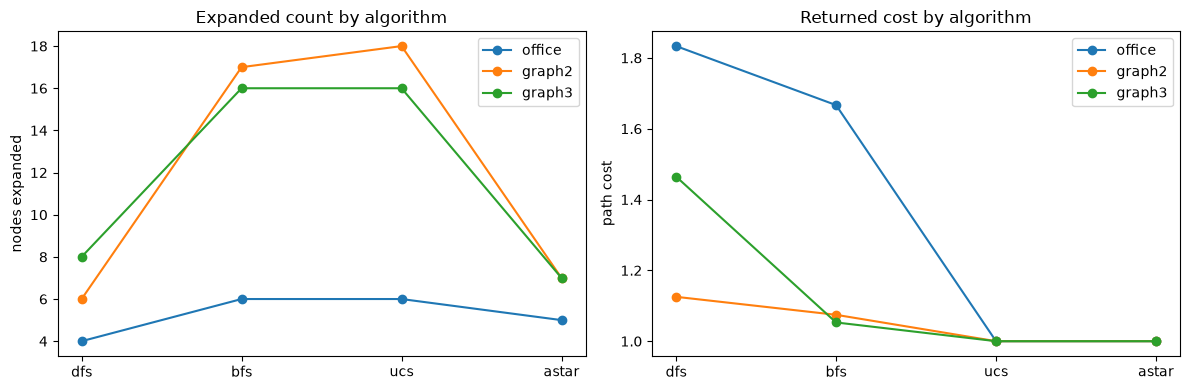

In [246]:
## MATPLOT IMPLEMENBTATION
%matplotlib inline
import matplotlib.pyplot as plt

algs = ["dfs", "bfs", "ucs", "astar"]
graphs = ["office", "graph2", "graph3"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for g in graphs:
    sub = [r for r in rows if r["graph"] == g]
    ax1.plot(algs, [r["expanded"] for r in sub], marker="o", label=g)
    opt = min(r["cost"] for r in sub)
    ax2.plot(algs, [r["cost"] / opt for r in sub], marker="o", label=g)
    
ax1.set_title("Expanded count by algorithm")
ax1.set_ylabel("nodes expanded")
ax2.set_title("Returned cost by algorithm")
ax2.set_ylabel("path cost")
ax1.legend(); ax2.legend()
plt.tight_layout()
plt.savefig("partB_comparison.png")   # saved copy for the submission zip
plt.show()

## Part C: A* heuristic behaviour analysis

The graphs chosen are **graph2.json** and **graph3.json**. 

This is because graph3 is small enough to hand inspect and reason about and graph2 is branching.

### C1.1 run UCS and A*
Plotted below are the graphs (in matplot and as a table if matplot isn't available).

In [339]:
def plot_graph(problem, paths=None, title="", fname=None):
    goal = problem["goal"]
    coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
    fig, ax = plt.subplots(figsize=(7, 7))

    for e in problem["edges"]:
        (x1, y1), (x2, y2) = coords[e["u"]], coords[e["v"]]
        ax.plot([x1, x2], [y1, y2], color="0.8", lw=1, zorder=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, f"{e['cost']}",
                ha="center", va="center", fontsize=5.5, color="0.55", zorder=2,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))

    for label, (path, color, style, gs) in (paths or {}).items():
        xs = [coords[n][0] for n in path]; ys = [coords[n][1] for n in path]
        ax.plot(xs, ys, color=color, lw=2.5, linestyle=style, zorder=2, label=label)
        if gs:
            for n, gval in zip(path, gs):
                x, y = coords[n]
                ax.text(x, y + 0.038, f"g={gval:.2f}", ha="center", va="bottom",
                        fontsize=6.5, color=color, zorder=4)

    for nid, (x, y) in coords.items():                # nodes on top
        endpoint = nid in (problem["start"], problem["goal"])
        ax.scatter(x, y, s=420, zorder=3,
                   color="#9fe1cb" if endpoint else "white",
                   edgecolors="#0f6e56" if endpoint else "0.4", linewidths=1)
        ax.text(x, y, nid, ha="center", va="center", zorder=4, fontsize=9)
        h = math.dist(coords[nid], coords[goal])
        ax.text(x, y - 0.048, f"h={h:.2f}", ha="center", va="top",
                fontsize=6.5, color="0.2", zorder=4)

    ax.set_aspect("equal")        # ← essential: preserves straight-line distances
    ax.axis("off")
    ax.set_title(title)
    if paths:
        ax.legend(loc="lower right", fontsize=8)
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

In [340]:
def plot_expansions(problem, expanded_order, title="", fname=None):
    coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
    fig, ax = plt.subplots(figsize=(7, 7))
    for e in problem["edges"]:
        (x1, y1), (x2, y2) = coords[e["u"]], coords[e["v"]]
        ax.plot([x1, x2], [y1, y2], color="0.8", lw=1, zorder=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, f"{e['cost']}",
                ha="center", va="center", fontsize=5.5, color="0.55", zorder=2,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))
    rank = {n: i + 1 for i, n in enumerate(expanded_order)}
    for nid, (x, y) in coords.items():
        hit = nid in rank
        ax.scatter(x, y, s=420, zorder=3, color="#fac775" if hit else "white",
                   edgecolors="#854f0b" if hit else "0.6", linewidths=1)
        ax.text(x, y, f"{nid}\n{rank[nid]}" if hit else nid,
                ha="center", va="center", fontsize=7, zorder=4)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title)
    if fname: plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

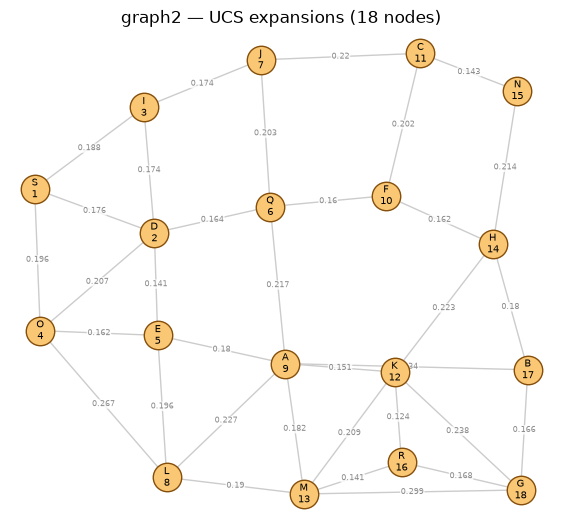

In [341]:
ucs_result   = solve_graph(problems["graph2"], "ucs")
plot_expansions(problems["graph2"], ucs_result["expanded_order"],
                title="graph2 — UCS expansions (18 nodes)",
                fname="partC_graph2_ucs_expansions.png")


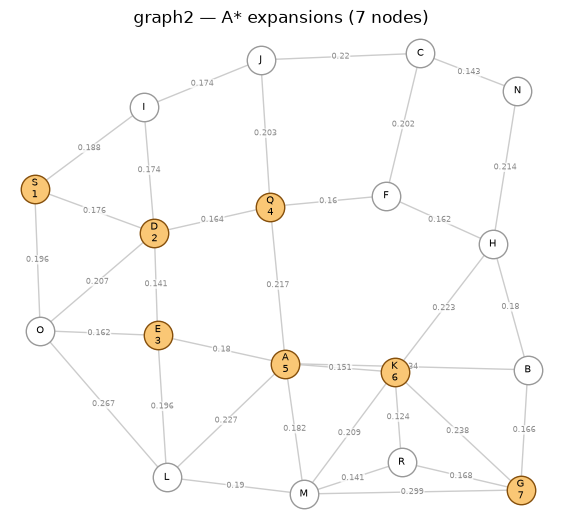

In [342]:
astar_result = solve_graph(problems["graph2"], "astar")
plot_expansions(problems["graph2"], astar_result["expanded_order"],
                title="graph2 — A* expansions (7 nodes)",
                fname="partC_graph2_astar_expansions.png")

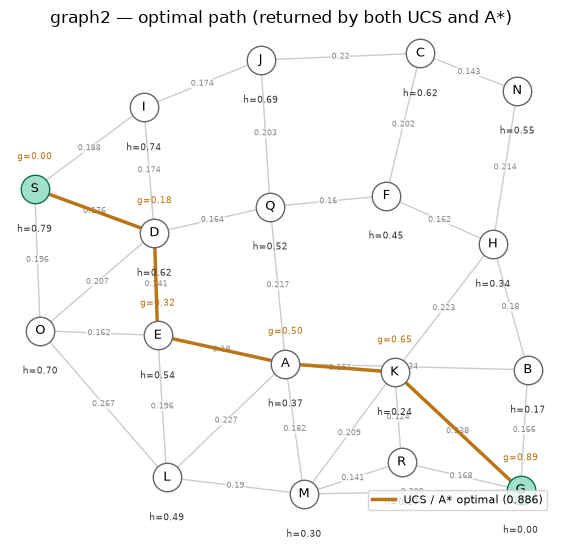

In [343]:
plot_graph(problems["graph2"],
           paths={"UCS / A* optimal (0.886)":
                  (["S", "D", "E", "A", "K", "G"], "#ba7517", "solid",
                   [0, 0.176, 0.317, 0.497, 0.648, 0.886])},
           title="graph2 — optimal path (returned by both UCS and A*)",
           fname="partC_graph2_optimal.png")

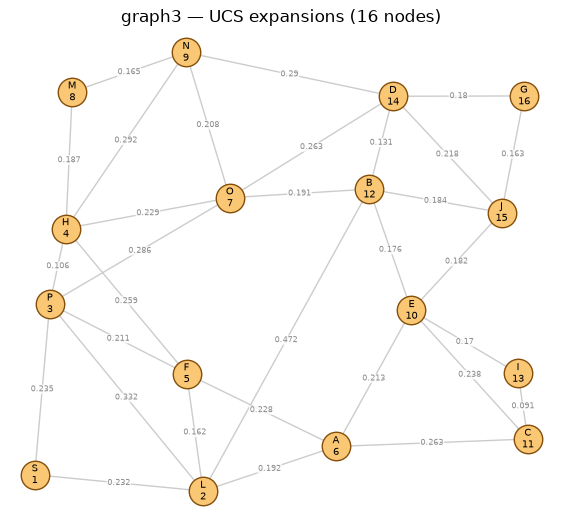

In [344]:
ucs_result   = solve_graph(problems["graph3"], "ucs")
plot_expansions(problems["graph3"], ucs_result["expanded_order"],
                title="graph3 — UCS expansions (16 nodes)",
                fname="partC_graph3_ucs_expansions.png")

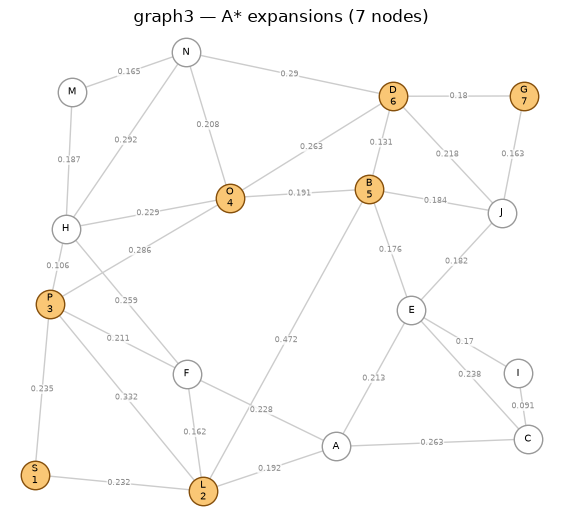

In [345]:
astar_result = solve_graph(problems["graph3"], "astar")
plot_expansions(problems["graph3"], astar_result["expanded_order"],
                title="graph3 — A* expansions (7 nodes)",
                fname="partC_graph2_astar_expansions.png")

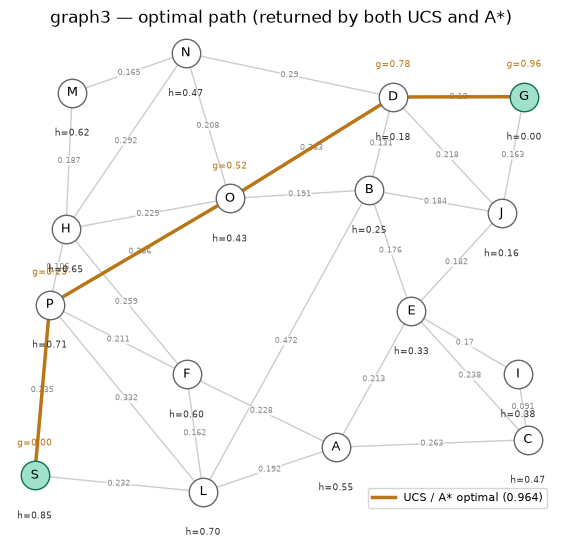

In [346]:
plot_graph(problems["graph3"],
           paths={"UCS / A* optimal (0.964)":
                  (["S", "P", "O", "D", "G"], "#ba7517", "solid",
                   [0, 0.235, 0.521, 0.784, 0.964])},
           title="graph3 — optimal path (returned by both UCS and A*)",
           fname="partC_graph3_optimal.png")

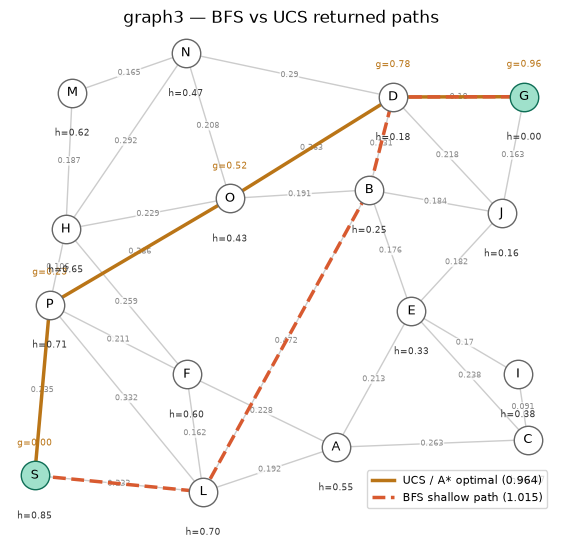

In [347]:
plot_graph(problems["graph3"],
           paths={"UCS / A* optimal (0.964)":
                  (["S", "P", "O", "D", "G"], "#ba7517", "solid",
                   [0, 0.235, 0.521, 0.784, 0.964]),
                  "BFS shallow path (1.015)":
                  (["S", "L", "B", "D", "G"], "#d85a30", "dashed", None)},
           title="graph3 — BFS vs UCS returned paths",
           fname="partB_graph3_paths.png")

In [352]:
## IF MATPLOT LIB ISN'T VISIBLE
def print_graph_text(problem, name=""):
    coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
    adj = build_adjacency(problem)
    goal = problem["goal"]

    print(f"=== {name}  (start: {problem['start']}, goal: {goal}) ===")
    print(f"{len(coords)} nodes, {len(problem['edges'])} edges\n")
    print(f"{'node':<10} {'(x, y)':<18} {'h to goal':>9}   neighbours (cost)")
    for nid in sorted(coords):
        x, y = coords[nid]
        h = math.dist(coords[nid], coords[goal])
        nbrs = ", ".join(f"{n} ({adj[nid][n]})" for n in sorted(adj[nid]))
        mark = " *" if nid in (problem["start"], goal) else "  "
        print(f"{nid:<8}{mark} ({x:.3f}, {y:.3f})   {h:>9.3f}   {nbrs}")
    print()

for pname, prob in problems.items():
    print_graph_text(prob, pname)

=== office  (start: corridor, goal: lab) ===
6 nodes, 8 edges

node       (x, y)             h to goal   neighbours (cost)
corridor * (0.000, 0.000)       2.000   mail_room (2.0), office_a (2.0), office_b (3.0)
lab      * (2.000, 0.000)       0.000   office_a (8.0), office_b (3.0), storage (7.0)
mail_room   (-1.000, 0.000)       3.000   corridor (2.0), storage (2.0)
office_a   (0.000, 1.000)       2.236   corridor (2.0), lab (8.0), office_b (2.0)
office_b   (1.000, 0.000)       1.000   corridor (3.0), lab (3.0), office_a (2.0)
storage    (-2.000, 0.000)       4.000   lab (7.0), mail_room (2.0)

=== graph2  (start: S, goal: G) ===
18 nodes, 34 edges

node       (x, y)             h to goal   neighbours (cost)
A          (0.502, 0.381)       0.368   B (0.334), E (0.18), K (0.151), L (0.227), M (0.182), Q (0.217)
B          (0.836, 0.372)       0.166   A (0.334), G (0.166), H (0.18)
C          (0.688, 0.808)       0.617   F (0.202), J (0.22), N (0.143)
D          (0.322, 0.561)       0.61

### C.2 Empirical Comparison
#### c.2.2 Comparisons

| Graph  | Algorithm | Returned cost | Expanded | Generated | Frontier peak |
|:-------|:----------|--------------:|---------:|----------:|--------------:|
| graph2 | UCS       | 0.886         | 18       | 64        | 13            |
| graph2 | A*        | 0.886         | 7        | 27        | 16            |
| graph3 | UCS       | 0.964         | 16       | 60        | 12            |
| graph3 | A*        | 0.964         | 7        | 27        | 13            |

#### c.2.3 Frontier entry
The frontier entry for graph2, UCS: (S, D, **I**, O, E,...) A\*: (S, D, **E**, Q, ...) Both open with S then D; the third expansion is the split: UCS pops the path ending at I, A\* pops the one ending at E.
Wheras for graph3 — UCS: S, L, P, **H**, F, ... / A*: S, L, P, **O** , B, ... Agreement for three, split at the fourth: H versus O. 

#### c.2.4 Heuristic change: 
The frontier of A* ordering splits on graph 2 (for example) at I for UCS because the total cost as E entry is f = g + h: f(E) = 0.317 + 0.544 = 0.861 versus f(I) = 0.188 + 0.740 = 0.928. Since g(S→I) = 0.188 is lower than g(S→D→E) = 0.317, UCS pops I. On graph3 the split at the fourth expansion works the same way: f(O) = 0.948 beats f(H) = 0.995, so A* pops O where UCS pops H

| Graph  | UCS expanded | A* expanded | Expanded by UCS but never by A* |
|:-------|-------------:|------------:|:--------------------------------|
| graph2 | 18           | 7           | I, O, J, L, F, C, M, H, N, R, B *(11 nodes)* |
| graph3 | 16           | 7           | H, F, A, M, N, E, C, I, J *(9 nodes)* |

| Graph  | Never expanded by A* (ordered by h, desc) |
|:-------|:------------------------------------------|
| graph2 | I (0.740), O (0.697), J (0.693), C (0.617), N (0.550), L (0.488), F (0.446), H (0.341), M (0.299), R (0.168), B (0.166) |
| graph3 | H (0.654), M (0.619), F (0.599), A (0.545), C (0.470), N (0.467), I (0.380), E (0.332), J (0.163) |

| Graph  | Expanded by A* (in expansion order, h shown) |
|:-------|:---------------------------------------------|
| graph2 | S (0.788), D (0.617), E (0.544), Q (0.521), A (0.368), K (0.238), G (0.000) |
| graph3 | S (0.848), L (0.698), P (0.710), O (0.427), B (0.248), D (0.180), G (0.000) |

| Graph  | A* expansions with g (in order) |
|:-------|:--------------------------------|
| graph2 | S (0), D (0.176), E (0.317), Q (0.340), A (0.497), K (0.648), G (0.886) |
| graph3 | S (0), L (0.232), P (0.235), O (0.521), B (0.712), D (0.784), G (0.964) |

#### c.2.5 Limitation on coordinate distance for graphs not modelling geometric distance
Edge costs need not model geometric distance and graphs can model many different things (not just geometry across a plane). If you built a 3d geometry inside of a sphere and wanted to reach a point on the other side of that plane. Euclidian distance for paths across the surface would work well, but may not if they require tracing through the centre of the internal geometry. Because edge costs here closely match geometric distance, h never overestimates the true remaining cost (it is admissible), so A*'s optimality is preserved — the limitation applies to graphs where costs and geometry diverge.

## Part D: STRIPS modelling and forward planning

### D.1 Plan diagnosis (lab_via_office_b)
1. First inapplicable action: ...
2. Missing precondition(s) / false fact(s): ...
3. Why inserting unlock_door alone isn't enough: ...
4. Repaired plan: ...
5. Where unlocked(lab_door) first becomes true: ...
6. How the final state satisfies at(parcel, lab): ...

In [349]:
def solve_planning(problem: dict) -> dict:
    """
    Forward BFS STRIPS planner.
    Returns a dict with the Table 2 fields (plan instead of path):
      status, plan, cost, expanded_order,
      expanded_count, generated_count, frontier_peak, (message)
    Use a canonical state id (e.g. sorted tuple of facts) for
    visited-tracking and expanded_order.
    """
    # TODO: implement forward BFS over fact-set states here.
    raise NotImplementedError

In [350]:
planning_files = {
    "canonical_delivery": "data/planning/canonical_delivery.json",
    "unlocked_lab": "data/planning/unlocked_lab.json",
}

for pname, ppath in planning_files.items():
    problem = load_problem(ppath)
    result = solve_planning(problem)
    print_result(pname, result)

NotImplementedError: 

## Reusable evaluation cell

Loads all supplied examples, runs every required algorithm, prints
a readable table, and writes the summary to zID_results.json.

In [209]:
summary = {}

# Graph problems: all four algorithms
for gname, gpath in graph_files.items():
    problem = load_problem(gpath)
    summary[gname] = {}
    for algo in ["dfs", "bfs", "ucs", "astar"]:
        summary[gname][algo] = solve_graph(problem, algo)

# Planning problems
for pname, ppath in planning_files.items():
    problem = load_problem(ppath)
    summary[pname] = solve_planning(problem)

# TODO: print summary as a readable table here.

with open("z5742721_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Wrote z5742721_results.json")

NameError: name 'graph_files' is not defined